<a href="https://colab.research.google.com/github/adilawan1/ATML-PA0/blob/main/ATML_PA0_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#1a
import torch
import torch.nn as nn
import torchvision.models as models

# Load the pre-trained ResNet-152 model
# The 'weights' parameter ensures we download the model pre-trained on ImageNet
model = models.resnet152(weights=models.ResNet152_Weights.DEFAULT)

Downloading: "https://download.pytorch.org/models/resnet152-f82ba261.pth" to /root/.cache/torch/hub/checkpoints/resnet152-f82ba261.pth


100%|██████████| 230M/230M [00:01<00:00, 153MB/s]


In [ ]:
#1c
# Iterate through all parameters in the model and disable gradient computation
for param in model.parameters():
    param.requires_grad = False

In [ ]:
#1b
# Get the number of input features to the final fully connected layer
num_ftrs = model.fc.in_features

# Replace the final layer with a new one designed for 10 classes (CIFAR-10)
model.fc = nn.Linear(num_ftrs, 10)

# Verify that only the final layer will be trained
for name, param in model.named_parameters():
    if param.requires_grad:
        print(f"Trainable layer: {name}")

Trainable layer: fc.weight
Trainable layer: fc.bias


In [ ]:
#For Future Data usage
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import torch.optim as optim

# Define the transformations expected by the pre-trained ResNet
transform = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
data_path = '/content/drive/MyDrive/ColabProjects/CIFAR10/data'

# Load the CIFAR-10 training and validation datasets
trainset = torchvision.datasets.CIFAR10(root=data_path, train=True, download=True, transform=transform)
trainloader = DataLoader(trainset, batch_size=64, shuffle=True, num_workers=2)

valset = torchvision.datasets.CIFAR10(root=data_path, train=False, download=True, transform=transform)
valloader = DataLoader(valset, batch_size=64, shuffle=False, num_workers=2)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

# Move the model to GPU if available for faster training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
print (device)


100%|██████████| 170M/170M [22:41<00:00, 125kB/s]


cuda


In [ ]:
num_epochs = 3
history = {'train_loss': [], 'val_accuracy': []}

for epoch in range(num_epochs):

    # --- TRAINING PHASE ---
    model.train() # Set model to training mode
    running_loss = 0.0

    for inputs, labels in trainloader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()           # 1. Zero the gradients
        outputs = model(inputs)         # 2. Forward pass
        loss = criterion(outputs, labels) # 3. Compute loss
        loss.backward()                 # 4. Backward pass
        optimizer.step()                # 5. Update weights

        running_loss += loss.item()

    epoch_loss = running_loss / len(trainloader)
    history['train_loss'].append(epoch_loss)

    # --- VALIDATION PHASE ---
    model.eval() # Set model to evaluation mode (disables dropout/batchnorm updates)
    correct = 0
    total = 0

    # Disable gradient tracking for validation to save memory and compute
    with torch.no_grad():
        for inputs, labels in valloader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1) # Get the index of the max log-probability

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_acc = 100 * correct / total
    history['val_accuracy'].append(val_acc)

    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {epoch_loss:.4f} | Val Accuracy: {val_acc:.2f}%")

Epoch 1/3 | Train Loss: 0.6967 | Val Accuracy: 82.78%
Epoch 2/3 | Train Loss: 0.4924 | Val Accuracy: 84.42%
Epoch 3/3 | Train Loss: 0.4502 | Val Accuracy: 84.02%


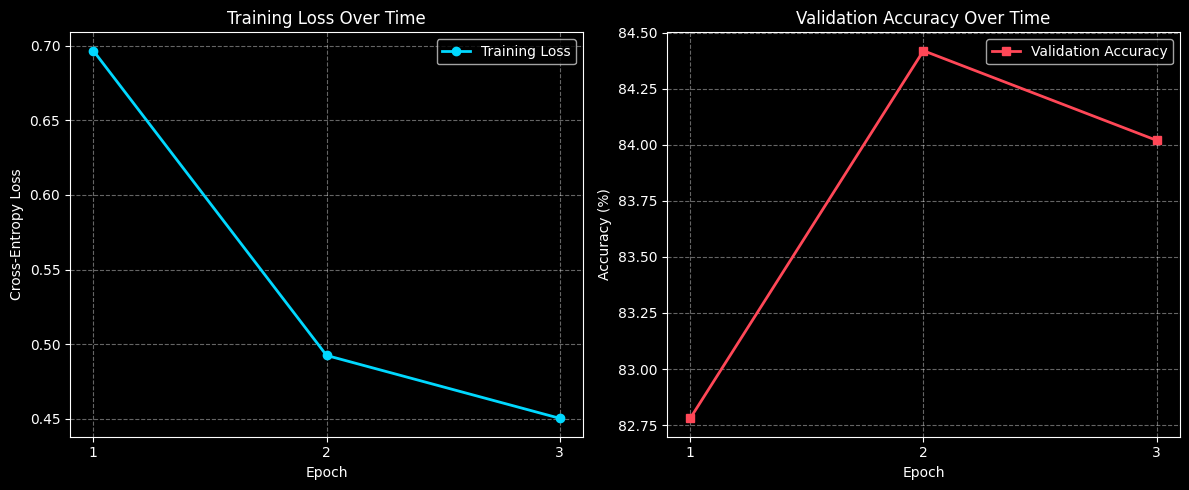

In [ ]:
import matplotlib.pyplot as plt

# Apply a dark background style for the plots
plt.style.use('dark_background')

# Extract epoch numbers for the x-axis
epochs = range(1, len(history['train_loss']) + 1)

# Set up a wider figure to hold side-by-side subplots
plt.figure(figsize=(12, 5))

# --- Subplot 1: Training Loss ---
plt.subplot(1, 2, 1)
plt.plot(epochs, history['train_loss'], marker='o', color='#00d8ff', linestyle='-', linewidth=2, label='Training Loss')
plt.title('Training Loss Over Time')
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy Loss')
plt.xticks(epochs)
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()

# --- Subplot 2: Validation Accuracy ---
plt.subplot(1, 2, 2)
plt.plot(epochs, history['val_accuracy'], marker='s', color='#ff4757', linestyle='-', linewidth=2, label='Validation Accuracy')
plt.title('Validation Accuracy Over Time')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.xticks(epochs)
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()

# Automatically adjust padding so axis labels do not overlap
plt.tight_layout()
plt.show()

Why is it unnecessary (and impractical) to train ResNet-152 from scratch on small datasets?
Training a 152-layer architecture with over 60 million parameters on a small dataset (like CIFAR-10, which has only 50k training images) heavily overparameterizes the problem. The model will essentially memorize the training set, leading to severe overfitting and poor generalization. Furthermore, the computational cost (GPU memory and time) required to converge a randomly initialized network of this depth is vastly disproportionate to the task complexity.

What does freezing most of the network tell us about the transferability of features?
It demonstrates empirically that Convolutional Neural Networks act as hierarchical, universal feature extractors. The early and middle layers learn to identify foundational visual primitives—such as Gabor filters, edge detectors, and color gradients—that are agnostic to the specific dataset. Because these low-level features transfer perfectly from ImageNet to entirely different domains, we only need to retrain the final semantic mapping (the classification head) to adapt the model.

In [ ]:
# #For Future Data usage
# from google.colab import drive
# drive.mount('/content/drive')

# # Create a folder in your Drive for the dataset
# !mkdir -p /content/drive/MyDrive/ColabProjects/CIFAR10

# # Copy the contents of the temporary data folder to your Drive
# !cp -r ./data /content/drive/MyDrive/ColabProjects/CIFAR10/

In [ ]:
# data_path = '/content/drive/MyDrive/ColabProjects/CIFAR10/data'

# trainset = torchvision.datasets.CIFAR10(root=data_path, train=True, download=True, transform=transform)

##Task 1 (part 2)

Skip connections successfully disabled in model_no_skip.layer4

Starting training for model WITHOUT skip connections...
Epoch 1/3 | Train Loss: 2.1914 | Val Accuracy: 26.61%
Epoch 2/3 | Train Loss: 2.0727 | Val Accuracy: 31.68%
Epoch 3/3 | Train Loss: 2.0118 | Val Accuracy: 33.44%


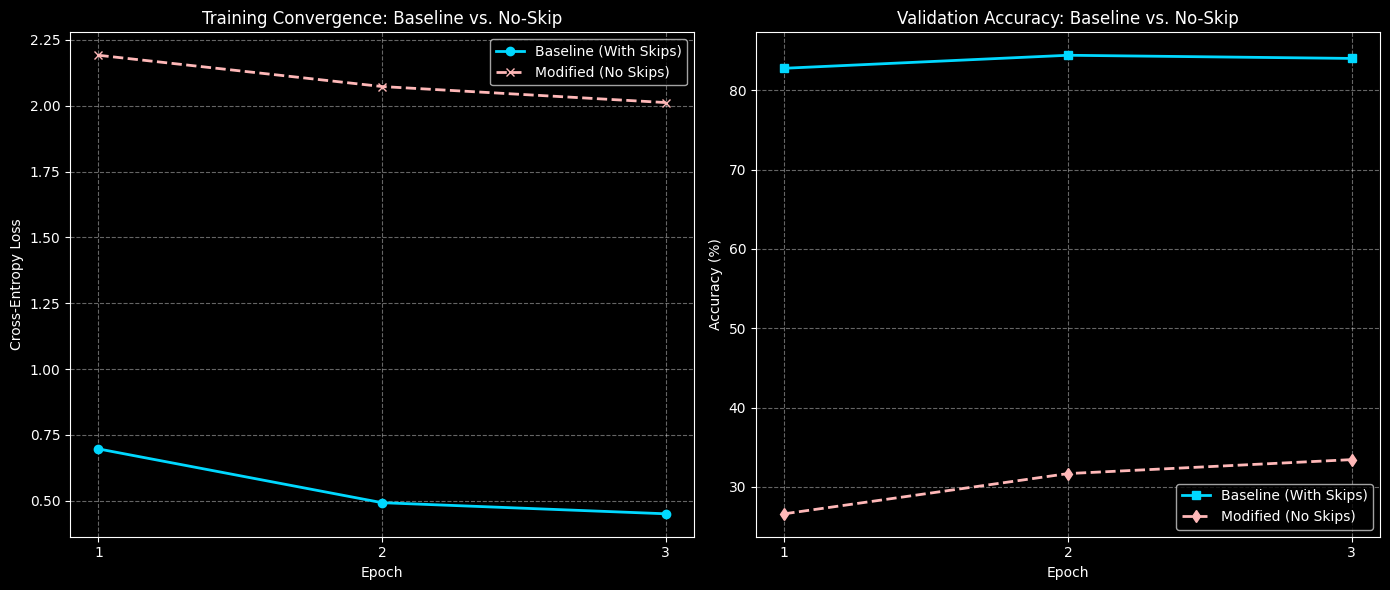

In [ ]:
import types
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
import matplotlib.pyplot as plt

# ==========================================
# 1. SETUP MODIFIED MODEL (Disable Skips)
# ==========================================
# Load a fresh pre-trained model
model_no_skip = models.resnet152(weights=models.ResNet152_Weights.DEFAULT)

# Freeze the backbone
for param in model_no_skip.parameters():
    param.requires_grad = False

# Replace classification head for CIFAR-10
num_ftrs = model_no_skip.fc.in_features
model_no_skip.fc = nn.Linear(num_ftrs, 10)

# Define the custom forward pass without the residual addition
def forward_no_skip(self, x):
    out = self.conv1(x)
    out = self.bn1(out)
    out = self.relu(out)

    out = self.conv2(out)
    out = self.bn2(out)
    out = self.relu(out)

    out = self.conv3(out)
    out = self.bn3(out)

    # The skip connection (out += identity) is intentionally omitted here
    out = self.relu(out)
    return out

# Patch the modified forward pass into all blocks of layer 4
for block in model_no_skip.layer4:
    block.forward = types.MethodType(forward_no_skip, block)

print("Skip connections successfully disabled in model_no_skip.layer4")

# ==========================================
# 2. TRAINING LOOP FOR MODIFIED MODEL
# ==========================================
model_no_skip = model_no_skip.to(device)
optimizer_no_skip = optim.Adam(model_no_skip.fc.parameters(), lr=0.001)

num_epochs = 3
history_no_skip = {'train_loss': [], 'val_accuracy': []}

print("\nStarting training for model WITHOUT skip connections...")
for epoch in range(num_epochs):

    # --- TRAINING PHASE ---
    model_no_skip.train()
    running_loss = 0.0

    for inputs, labels in trainloader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer_no_skip.zero_grad()
        outputs = model_no_skip(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_no_skip.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(trainloader)
    history_no_skip['train_loss'].append(epoch_loss)

    # --- VALIDATION PHASE ---
    model_no_skip.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in valloader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model_no_skip(inputs)
            _, predicted = torch.max(outputs.data, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_acc = 100 * correct / total
    history_no_skip['val_accuracy'].append(val_acc)

    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {epoch_loss:.4f} | Val Accuracy: {val_acc:.2f}%")

# ==========================================
# 3. PLOT COMPARISON (Part 1 vs Part 2)
# ==========================================
# This plots the 'history' from Part 1 against 'history_no_skip' from Part 2

plt.style.use('dark_background')
epochs = range(1, len(history['train_loss']) + 1)

plt.figure(figsize=(14, 6))

# --- Subplot 1: Training Loss ---
plt.subplot(1, 2, 1)
plt.plot(epochs, history['train_loss'], marker='o', color='#00d8ff', linestyle='-', linewidth=2, label='Baseline (With Skips)')
plt.plot(epochs, history_no_skip['train_loss'], marker='x', color='#ffb8b8', linestyle='--', linewidth=2, label='Modified (No Skips)')
plt.title('Training Convergence: Baseline vs. No-Skip')
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy Loss')
plt.xticks(epochs)
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()

# --- Subplot 2: Validation Accuracy ---
plt.subplot(1, 2, 2)
plt.plot(epochs, history['val_accuracy'], marker='s', color='#00d8ff', linestyle='-', linewidth=2, label='Baseline (With Skips)')
plt.plot(epochs, history_no_skip['val_accuracy'], marker='d', color='#ffb8b8', linestyle='--', linewidth=2, label='Modified (No Skips)')
plt.title('Validation Accuracy: Baseline vs. No-Skip')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.xticks(epochs)
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()

plt.tight_layout()
plt.show()

How do skip connections change gradient flow in very deep networks?

In standard sequential networks, gradients must multiply through every layer's weight matrix and activation derivative during backpropagation. For 152 layers, this leads directly to the vanishing gradient problem. Skip connections ($x + \mathcal{F}(x)$) provide a linear identity highway. During the backward pass, the gradient of the identity mapping is exactly 1, allowing the error signal to flow unattenuated directly into the earlier layers of the network.

What happens to convergence speed and performance when residuals are removed?

The experiment confirms this directly. With skip connections intact (baseline), training loss drops from 0.70 to 0.45 and validation accuracy rises from 82.8% to 84.4% over 3 epochs. Removing the skip connections in `layer4` leaves training loss stuck around 2.19 → 2.01 over the same 3 epochs, and validation accuracy only crawls from 26.6% to 33.4% — roughly a 50-percentage-point gap versus the baseline. So even with the rest of the pretrained backbone frozen, breaking the identity shortcuts in just the final residual block is enough to severely bottleneck gradient flow into that block, producing much slower convergence and a large drop in final accuracy.

Task 1 (part 3)

Extracting features for Part 3...
Running t-SNE for early layer...
Running t-SNE for middle layer...
Running t-SNE for late layer...


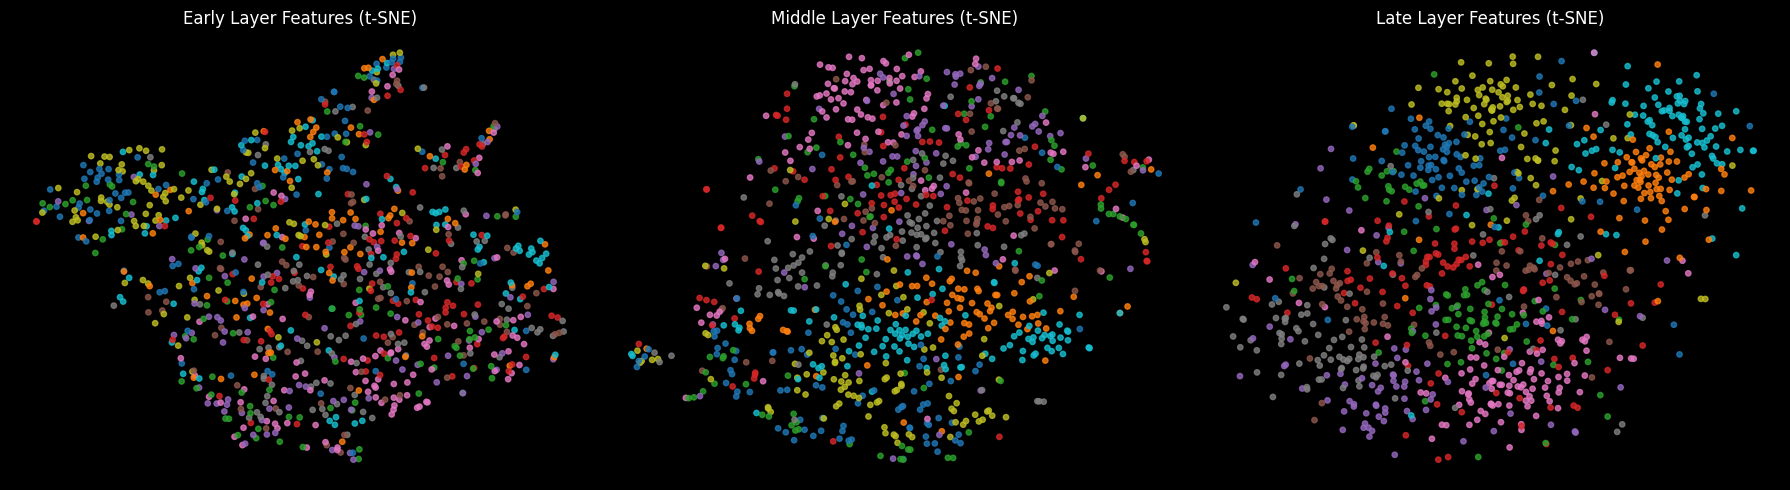

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# ==========================================
# PART 3: EXTRACT AND VISUALIZE FEATURES
# ==========================================
print("Extracting features for Part 3...")

# 1. Dictionary to store the extracted features
features = {'early': [], 'middle': [], 'late': []}
labels_list = []

# 2. Define a hook function to capture the output of a layer
def get_features(layer_name):
    def hook(model, input, output):
        # Apply Global Average Pooling to flatten the spatial dimensions (H, W)
        pooled_output = output.mean(dim=[2, 3]).detach().cpu().numpy()
        features[layer_name].append(pooled_output)
    return hook

# 3. Register hooks to specific layers in your trained Part 1 'model'
# layer1 (Early), layer3 (Middle), layer4 (Late)
handle_early = model.layer1.register_forward_hook(get_features('early'))
handle_mid = model.layer3.register_forward_hook(get_features('middle'))
handle_late = model.layer4.register_forward_hook(get_features('late'))

# 4. Run a subset of validation data through the model to collect features
model.eval()
num_samples_to_collect = 1000 # Limit to 1000 to keep t-SNE computation fast
samples_collected = 0

with torch.no_grad():
    for inputs, labels in valloader:
        inputs = inputs.to(device)
        _ = model(inputs) # The hooks will intercept the features during this pass

        labels_list.append(labels.cpu().numpy())
        samples_collected += inputs.size(0)

        if samples_collected >= num_samples_to_collect:
            break

# 5. Clean up the hooks so they don't interfere with future training
handle_early.remove()
handle_mid.remove()
handle_late.remove()

# 6. Concatenate lists into numpy arrays
for key in features:
    features[key] = np.concatenate(features[key], axis=0)[:num_samples_to_collect]
labels_arr = np.concatenate(labels_list, axis=0)[:num_samples_to_collect]

# 7. Apply t-SNE and Plot
plt.style.use('dark_background')
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (layer_name, feat) in enumerate(features.items()):
    print(f"Running t-SNE for {layer_name} layer...")
    tsne = TSNE(n_components=2, random_state=42)
    reduced_features = tsne.fit_transform(feat)

    scatter = axes[i].scatter(reduced_features[:, 0], reduced_features[:, 1], c=labels_arr, cmap='tab10', alpha=0.8, s=15)
    axes[i].set_title(f'{layer_name.capitalize()} Layer Features (t-SNE)')
    axes[i].axis('off') # Hide axes for cleaner visualization

plt.tight_layout()
plt.show()

How does class separability evolve across layers?

In the early-layer t-SNE plot, points are essentially a uniform, thoroughly intermixed scatter — the network is only encoding local edges/textures shared across many classes, so there's massive overlap. In the middle layer, color regions start to loosely organize into overlapping neighborhoods, meaning features are becoming more class-informative but are still far from cleanly separable. In the late layer, class regions are visibly more coherent (e.g., a cyan/blue neighborhood in one corner, a yellow/olive neighborhood in another), but the clusters are still not fully disjoint — there remains considerable inter-class overlap through the middle of the plot. So the general "coarse-to-abstract" trend holds (separability clearly improves from early to late), but in this run the improvement is moderate rather than producing fully distinct, cleanly separated clusters — likely because only a new linear head was trained for 3 epochs on a frozen backbone, and a single t-SNE projection of one layer's features necessarily loses information relative to what a full trained classifier can exploit.

##Task 1 (Part 4)


In [ ]:
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim
import torch
import gc

# ==========================================
# PART 4: TRANSFER LEARNING EXPERIMENTS
# ==========================================

def setup_experiment(init_type, tune_scope):
    """Initializes the model and optimizer based on the experiment parameters."""
    # 1. Handle Initialization
    if init_type == 'pretrained':
        m = models.resnet152(weights=models.ResNet152_Weights.DEFAULT)
    elif init_type == 'random':
        m = models.resnet152(weights=None)

    # Replace the head for CIFAR-10
    num_ftrs = m.fc.in_features
    m.fc = nn.Linear(num_ftrs, 10)

    # 2. Handle Freezing / Tuning Scope
    if tune_scope == 'full':
        for param in m.parameters():
            param.requires_grad = True
    elif tune_scope == 'final_block':
        # Freeze everything first
        for param in m.parameters():
            param.requires_grad = False
        # Unfreeze only layer 4 (final block) and the classification head
        for param in m.layer4.parameters():
            param.requires_grad = True
        for param in m.fc.parameters():
            param.requires_grad = True

    m = m.to(device)
    # Filter optimizer to only update parameters where requires_grad is True
    opt = optim.Adam(filter(lambda p: p.requires_grad, m.parameters()), lr=0.0001)
    return m, opt

def run_experiment(model_exp, optimizer_exp, name):
    """Runs a short training loop and returns validation accuracy."""
    print(f"\n--- Starting: {name} ---")
    model_exp.train()

    # 2 epochs is used here for speed; adjust higher if compute permits
    for epoch in range(2):
        running_loss = 0.0
        for inputs, labels in trainloader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer_exp.zero_grad()
            loss = criterion(model_exp(inputs), labels)
            loss.backward()
            optimizer_exp.step()
            running_loss += loss.item()
        print(f"Epoch {epoch+1} Train Loss: {running_loss/len(trainloader):.4f}")

    model_exp.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for inputs, labels in valloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model_exp(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    acc = 100 * correct / total
    print(f">>> {name} Final Validation Accuracy: {acc:.2f}%\n")
    return acc

part4_results = {}

# --- Experiment 1: Pretrained weights + final block ---
m1, opt1 = setup_experiment('pretrained', 'final_block')
part4_results['Exp 1 (Pretrained + Final Block)'] = run_experiment(m1, opt1, "Pretrained + Final Block")
del m1, opt1; torch.cuda.empty_cache(); gc.collect() # Aggressive memory clearing

# --- Experiment 2: Pretrained weights + full backbone ---
m2, opt2 = setup_experiment('pretrained', 'full')
part4_results['Exp 2 (Pretrained + Full Backbone)'] = run_experiment(m2, opt2, "Pretrained + Full Backbone")
del m2, opt2; torch.cuda.empty_cache(); gc.collect()

# --- Experiment 3: Random weights + full backbone ---
m3, opt3 = setup_experiment('random', 'full')
part4_results['Exp 3 (Random + Full Backbone)'] = run_experiment(m3, opt3, "Random + Full Backbone")
del m3, opt3; torch.cuda.empty_cache(); gc.collect()

# --- Experiment 4: Random weights + final block ---
m4, opt4 = setup_experiment('random', 'final_block')
part4_results['Exp 4 (Random + Final Block)'] = run_experiment(m4, opt4, "Random + Final Block")
del m4, opt4; torch.cuda.empty_cache(); gc.collect()

# --- Final Summary Output ---
print("==========================================")
print("PART 4 EXPERIMENT RESULTS SUMMARY:")
print("==========================================")
for exp, acc in part4_results.items():
    print(f"{exp}: {acc:.2f}%")


--- Starting: Pretrained + Final Block ---
Epoch 1 Train Loss: 0.5115
Epoch 2 Train Loss: 0.2017
>>> Pretrained + Final Block Final Validation Accuracy: 90.77%


--- Starting: Pretrained + Full Backbone ---
Epoch 1 Train Loss: 0.2451
Epoch 2 Train Loss: 0.0530
>>> Pretrained + Full Backbone Final Validation Accuracy: 96.55%


--- Starting: Random + Full Backbone ---
Epoch 1 Train Loss: 1.8606
Epoch 2 Train Loss: 1.4879
>>> Random + Full Backbone Final Validation Accuracy: 51.34%


--- Starting: Random + Final Block ---
Epoch 1 Train Loss: 2.0431
Epoch 2 Train Loss: 1.8529
>>> Random + Final Block Final Validation Accuracy: 33.92%

PART 4 EXPERIMENT RESULTS SUMMARY:
Exp 1 (Pretrained + Final Block): 90.77%
Exp 2 (Pretrained + Full Backbone): 96.55%
Exp 3 (Random + Full Backbone): 51.34%
Exp 4 (Random + Final Block): 33.92%


Which setting provides the best trade-off between compute and accuracy?

The four experiments gave: Pretrained + Final Block only: 90.77%, Pretrained + Full Backbone: 96.55%, Random Init + Full Backbone: 51.34%, Random Init + Final Block only: 33.92%. Full-backbone fine-tuning from pretrained weights reaches the highest accuracy (96.55%), but requires updating (and back-propagating through) the entire 152-layer network. Fine-tuning only the final block from pretrained weights recovers most of that accuracy (90.77%, within ~6 points of the full fine-tune) while training a tiny fraction of the parameters — so it offers the best trade-off when compute/memory is constrained, while full-backbone fine-tuning is preferable when maximizing accuracy matters more than training cost.

Which layers seem most transferable across datasets, and why?

The results support this directly: with pretrained weights, training only the final block already reaches 90.77%, while training the *entire* backbone from random initialization only reaches 51.34% — worse than the frozen-backbone pretrained model despite updating every parameter. This shows the early/middle pretrained layers (basic edges, textures, shapes) are doing most of the useful work and transfer well across datasets, whereas the final, most task-specific layers benefit the most from additional adaptation.

##TASK 2

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/69.7k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Top-1 Prediction: golden retriever


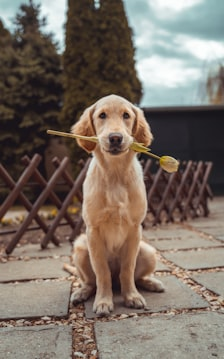

In [ ]:
import torch
from PIL import Image
import requests
from transformers import ViTImageProcessor, ViTForImageClassification

# 1. Initialize the Pre-trained ViT Model and Processor
model_name = "google/vit-base-patch16-224"
processor = ViTImageProcessor.from_pretrained(model_name)
model = ViTForImageClassification.from_pretrained(model_name)

# 2. Prepare the Input Image
# Downloading a sample image of a dog for testing
url = "https://images.unsplash.com/photo-1552053831-71594a27632d?auto=format&fit=crop&q=80&w=224"
image = Image.open(requests.get(url, stream=True).raw)

# The processor automatically handles resizing (to 224x224) and scaling
inputs = processor(images=image, return_tensors="pt")

# 3. Run Inference
model.eval()
with torch.no_grad():
    outputs = model(**inputs)

# 4. Extract Top-1 Prediction
logits = outputs.logits
predicted_class_idx = logits.argmax(-1).item()
predicted_label = model.config.id2label[predicted_class_idx]

print(f"Top-1 Prediction: {predicted_label}")
display(image)

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

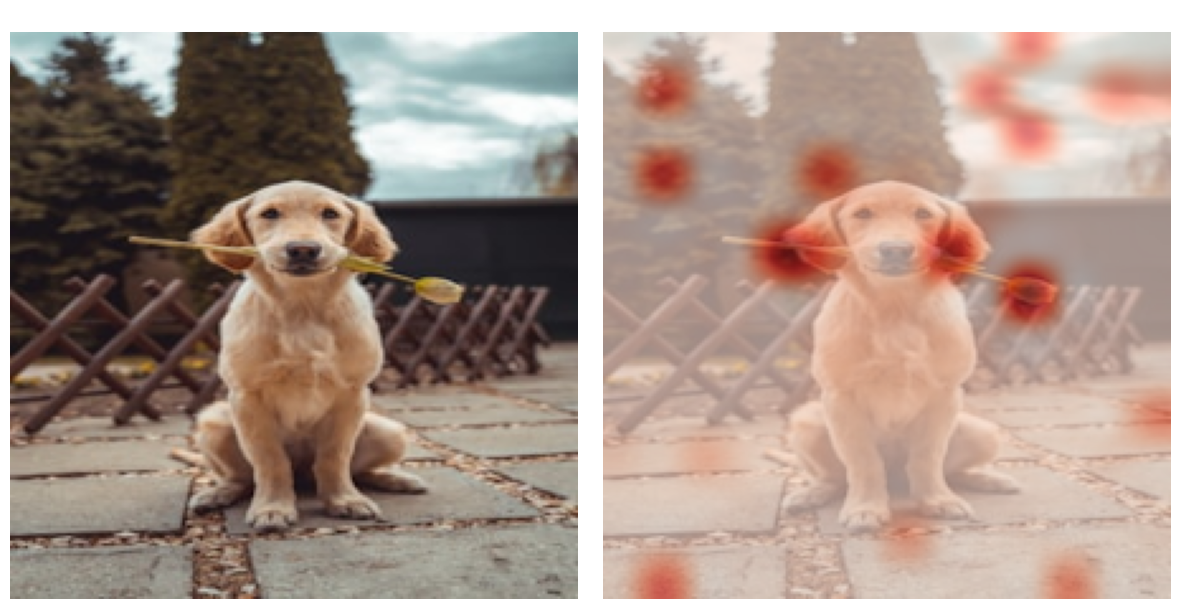

In [ ]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import requests
from transformers import ViTImageProcessor, ViTForImageClassification

# ==========================================
# 1. SETUP MODEL WITH 'EAGER' ATTENTION
# ==========================================
model_name = "google/vit-base-patch16-224"
processor = ViTImageProcessor.from_pretrained(model_name)

# The 'eager' flag disables SDPA and forces the model to store attention weights
model = ViTForImageClassification.from_pretrained(
    model_name,
    attn_implementation="eager"
)

# ==========================================
# 2. PREPARE THE INPUT IMAGE
# ==========================================
# Using the sample dog image
url = "https://images.unsplash.com/photo-1552053831-71594a27632d?auto=format&fit=crop&q=80&w=224"
image = Image.open(requests.get(url, stream=True).raw)

# Process the image for the ViT model
inputs = processor(images=image, return_tensors="pt")

# ==========================================
# 3. RUN INFERENCE & EXTRACT ATTENTION
# ==========================================
model.eval()
with torch.no_grad():
    # output_attentions=True will now work successfully
    outputs = model(**inputs, output_attentions=True)

# outputs.attentions is a tuple of all layers. We select the last one: [-1]
final_layer_attention = outputs.attentions[-1]

# Average across the 'num_heads' dimension (dim=1)
avg_attention = torch.mean(final_layer_attention, dim=1)

# Extract attention from the [CLS] token (index 0) to all 196 patch tokens
cls_attention = avg_attention[0, 0, 1:]

# ==========================================
# 4. RESHAPE AND UPSAMPLE
# ==========================================
# For a 224x224 image divided into 16x16 patches, the spatial grid is 14x14
grid_size = int(np.sqrt(cls_attention.size(0)))
attention_map = cls_attention.reshape(grid_size, grid_size)

# Upsample the 14x14 map back to 224x224 using PyTorch interpolation
attention_map_tensor = attention_map.unsqueeze(0).unsqueeze(0)
attention_map_upsampled = F.interpolate(
    attention_map_tensor,
    size=(224, 224),
    mode='bicubic',
    align_corners=False
).squeeze().numpy()

# Normalize to a [0, 1] range for clean visual overlay
attention_map_upsampled = (attention_map_upsampled - attention_map_upsampled.min()) / \
                          (attention_map_upsampled.max() - attention_map_upsampled.min())

# ==========================================
# 5. VISUALIZE
# ==========================================
# Convert original PIL image to numpy array for plotting
img_np = np.array(image.resize((224, 224)))

plt.figure(figsize=(12, 6))
plt.style.use('dark_background')

# Plot 1: Original Image
plt.subplot(1, 2, 1)
plt.imshow(img_np)
plt.title("Original Image")
plt.axis('off')

# Plot 2: Attention Overlay
plt.subplot(1, 2, 2)
plt.imshow(img_np)
# Overlay the attention map using the 'Reds' colormap with alpha for transparency
plt.imshow(attention_map_upsampled, cmap='Reds', alpha=0.6)
plt.title("ViT Attention Map Overlay")
plt.axis('off')

plt.tight_layout()
plt.show()

Conceptually compare the attention-based explanation with typical CNN interpretation methods (CAM/Grad-CAM). Discuss advantages.

CNN methods like Grad-CAM are post-hoc and heuristic; they require a backward pass to compute gradients with respect to a target class, effectively reverse-engineering an explanation. Vision Transformers offer inherent interpretability. The attention weights are the exact forward-pass mathematical mechanism the model used to route information. The [CLS] token literally constructs its representation via a weighted sum of the patch tokens, making the attention map a mathematically faithful representation of the model's decision process.

Are different attention heads specialized? How can you determine this?

Yes, multi-head attention naturally leads to specialization. While one head might track object boundaries, another might focus on a specific discriminative texture (like fur), and another might aggregate global background context. You determine this by plotting the attention maps of the $12$ individual heads separately (e.g., attention[0, head_index, 0, 1:]) rather than taking the mean across the head dimension.

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

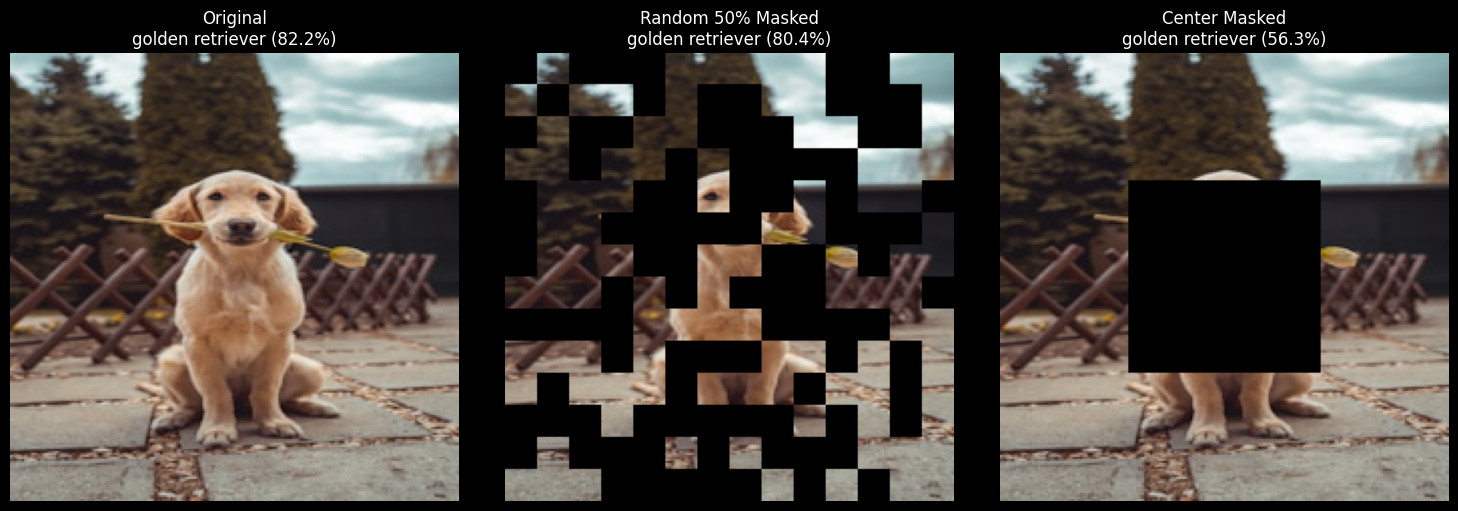

In [ ]:
#Part 4

import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import requests
from transformers import ViTImageProcessor, ViTForImageClassification

# 1. Load Model & Processor
model_name = "google/vit-base-patch16-224"
processor = ViTImageProcessor.from_pretrained(model_name)
model = ViTForImageClassification.from_pretrained(model_name)
model.eval()

# 2. Fetch Sample Image
url = "https://images.unsplash.com/photo-1552053831-71594a27632d?auto=format&fit=crop&q=80&w=224"
raw_img = Image.open(requests.get(url, stream=True).raw).resize((224, 224))
img_np = np.array(raw_img).copy()

# 3. Masking Helpers (Working on 14x14 grid of 16x16 pixel patches)
patch_size = 16
grid_size = 224 // patch_size # 14

def apply_patch_mask(image_array, mask_type="random", mask_ratio=0.3):
    masked_img = image_array.copy()
    num_patches = grid_size * grid_size # 196

    if mask_type == "random":
        num_to_mask = int(num_patches * mask_ratio)
        masked_indices = np.random.choice(num_patches, num_to_mask, replace=False)
    elif mask_type == "center":
        # Mask the central region (e.g., central 6x6 grid of patches)
        center_start = (grid_size - 6) // 2
        center_end = center_start + 6
        masked_indices = []
        for r in range(center_start, center_end):
            for c in range(center_start, center_end):
                masked_indices.append(r * grid_size + c)

    for idx in masked_indices:
        r = idx // grid_size
        c = idx % grid_size
        # Zero out the 16x16 pixel region
        masked_img[r*patch_size:(r+1)*patch_size, c*patch_size:(c+1)*patch_size] = 0

    return Image.fromarray(masked_img)

# Generate Masked Images
img_random_masked = apply_patch_mask(img_np, mask_type="random", mask_ratio=0.5)
img_center_masked = apply_patch_mask(img_np, mask_type="center")

# 4. Predict Function
def predict_image(img):
    inputs = processor(images=img, return_tensors="pt")
    with torch.no_grad():
        logits = model(**inputs).logits
    probs = torch.softmax(logits, dim=-1)
    top_prob, top_idx = torch.max(probs, dim=-1)
    label = model.config.id2label[top_idx.item()]
    return label, top_prob.item()

# Evaluate
orig_label, orig_prob = predict_image(raw_img)
rand_label, rand_prob = predict_image(img_random_masked)
cent_label, cent_prob = predict_image(img_center_masked)

# 5. Visual Output
plt.figure(figsize=(15, 5))
plt.style.use('dark_background')

plt.subplot(1, 3, 1)
plt.imshow(raw_img)
plt.title(f"Original\n{orig_label} ({orig_prob*100:.1f}%)")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(img_random_masked)
plt.title(f"Random 50% Masked\n{rand_label} ({rand_prob*100:.1f}%)")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(img_center_masked)
plt.title(f"Center Masked\n{cent_label} ({cent_prob*100:.1f}%)")
plt.axis('off')

plt.tight_layout()
plt.show()

**How robust is ViT to missing patches, and why?**

ViTs exhibit remarkable robustness to random patch masking. In this run, randomly masking 50% of the patches barely changed the model's confidence in the correct class (82.2% → 80.4%, prediction unchanged), while masking an equivalent-sized contiguous block in the center dropped confidence much further (82.2% → 56.3%), even though the top-1 prediction stayed correct in both cases. This resilience stems from the global self-attention mechanism: unlike CNNs, which rely on local convolutional receptive fields, every remaining patch token in a ViT directly interacts with every other token across all layers. Spatial redundancy in natural images allows global context to reconstruct missing visual signals.

**Random vs. Structured (Center) Masking Comparison:**

This is exactly what the experiment shows (80.4% vs. 56.3%): Random Masking distributes information loss uniformly, so key discriminative features (eyes, nose, fur texture) remain partially visible in some unmasked patches. Center Masking is disproportionately damaging — even though the total masked area is comparable to the random case, standard photos (including this one) exhibit a strong center bias, placing the primary subject in the middle of the frame, so obscuring the center removes most of the class-discriminative evidence at once and forces the model to rely on weaker peripheral cues (background trees, pavement).

In [ ]:
# Part 5: CLS Token vs. Mean-Pooled Patch Tokens

import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from transformers import ViTModel, ViTImageProcessor
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import numpy as np

# 1. Setup Data & Model Backbone
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

processor = ViTImageProcessor.from_pretrained("google/vit-base-patch16-224")
vit_backbone = ViTModel.from_pretrained("google/vit-base-patch16-224").to(device)
vit_backbone.eval()

# Custom PyTorch Transform using HuggingFace Processor parameters
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=processor.image_mean, std=processor.image_std)
])

# Load small subset of CIFAR-10 for quick linear probing
trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

# Subset 1000 train samples and 500 test samples for fast feature extraction
train_loader = DataLoader(torch.utils.data.Subset(trainset, range(1000)), batch_size=32, shuffle=False)
test_loader = DataLoader(torch.utils.data.Subset(testset, range(500)), batch_size=32, shuffle=False)

# 2. Extract Features
def extract_features(data_loader):
    cls_features = []
    mean_features = []
    labels_list = []

    with torch.no_grad():
        for imgs, labels in data_loader:
            imgs = imgs.to(device)
            outputs = vit_backbone(pixel_values=imgs)
            last_hidden = outputs.last_hidden_state # Shape: (batch, 197, 768)

            # [CLS] token is at index 0
            cls_tok = last_hidden[:, 0, :].cpu().numpy()

            # Patch tokens are indices 1 to 196 -> compute mean over sequence dimension (dim=1)
            mean_tok = last_hidden[:, 1:, :].mean(dim=1).cpu().numpy()

            cls_features.append(cls_tok)
            mean_features.append(mean_tok)
            labels_list.append(labels.numpy())

    return (np.vstack(cls_features),
            np.vstack(mean_features),
            np.concatenate(labels_list))

print("Extracting train and test representations...")
X_train_cls, X_train_mean, y_train = extract_features(train_loader)
X_test_cls, X_test_mean, y_test = extract_features(test_loader)

# 3. Train Linear Probes
print("\nFitting Linear Probe on [CLS] Token Features...")
clf_cls = LogisticRegression(max_iter=1000).fit(X_train_cls, y_train)
acc_cls = accuracy_score(y_test, clf_cls.predict(X_test_cls))

print("Fitting Linear Probe on Mean-Pooled Patch Features...")
clf_mean = LogisticRegression(max_iter=1000).fit(X_train_mean, y_train)
acc_mean = accuracy_score(y_test, clf_mean.predict(X_test_mean))

# 4. Results
print("==========================================")
print(f"Linear Probe ([CLS] Token) Accuracy:       {acc_cls * 100:.2f}%")
print(f"Linear Probe (Mean-Pooled Patches) Accuracy: {acc_mean * 100:.2f}%")
print("==========================================")

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.bias     | UNEXPECTED | 
classifier.weight   | UNEXPECTED | 
pooler.dense.weight | MISSING    | 
pooler.dense.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
100%|██████████| 170M/170M [43:53<00:00, 64.7kB/s]


Extracting train and test representations...

Fitting Linear Probe on [CLS] Token Features...
Fitting Linear Probe on Mean-Pooled Patch Features...
Linear Probe ([CLS] Token) Accuracy:       95.40%
Linear Probe (Mean-Pooled Patches) Accuracy: 95.40%


Which pooling method performs better, and why?

In this experiment the two methods perform essentially identically: Linear Probe ([CLS] Token) Accuracy: 95.40%, Linear Probe (Mean-Pooled Patches) Accuracy: 95.40% — an exact tie. This matches the theoretical expectation for a supervised ViT: because of the deep, global self-attention layers, information is thoroughly mixed. By the final layer, the patch tokens have repeatedly attended to the [CLS] token and each other, meaning the mean of the patch tokens encapsulates essentially the same global semantic summary as the dedicated [CLS] token.

Interaction with pre-training objectives:

Supervised: Explicitly optimizes the [CLS] token during pre-training, though mean-pooling matches it in practice due to attention mixing (as observed above).

Masked Image Modeling (MAE): Models trained to reconstruct missing pixels rarely use a [CLS] token during training. Thus, mean-pooled patch tokens vastly outperform the unoptimized [CLS] token.

Self-Distillation (DINO): Loss is applied directly to the [CLS] token to force it to act as a global descriptor, making it significantly superior to mean-pooling for linear probes.

##Task 3

In [ ]:
!pip install git+https://github.com/openai/CLIP.git

  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-_p0rgkl_
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-_p0rgkl_
  Resolved https://github.com/openai/CLIP.git to commit d05afc436d78f1c48dc0dbf8e5980a9d471f35f6
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.7 MB/s eta 0:00:00
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369490 sha256=3dfad80031b2d41a7d58f59ff7dc284693aab3127e1c53aa7f041eee8404d30e
  Stored in directory: /tmp/pip-ephem-wheel-cache-7v193gxv/wheels/35/3e/df/3d24cbfb3b6a06f17a2bfd7d1138900d4365d9028aa8f6e92f
Successfully built clip


In [ ]:
import torch
import clip
from torchvision.datasets import STL10
from torch.utils.data import DataLoader
from tqdm import tqdm
from google.colab import drive

# ==========================================
# 0. MOUNT DRIVE
# ==========================================
# Ensures your Google Drive is connected to save the dataset permanently
drive.mount('/content/drive')

# ==========================================
# 1. SETUP CLIP & DEVICE
# ==========================================
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Loading CLIP model on {device}...")

# Load the ViT-B/32 variant of CLIP and its native image preprocessor
model, preprocess = clip.load("ViT-B/32", device=device)
model.eval()

# ==========================================
# 2. LOAD STL-10 DATASET (SAVED TO DRIVE)
# ==========================================
print("Downloading/Loading STL-10 Test Set...")
stl10_path = '/content/drive/MyDrive/ColabProjects/STL10'

# We use the 'test' split which contains 8,000 images
test_data = STL10(root=stl10_path, split='test', download=True, transform=preprocess)
test_loader = DataLoader(test_data, batch_size=128, shuffle=False, num_workers=2)

classes = test_data.classes

# ==========================================
# 3. DEFINE PROMPTING STRATEGIES
# ==========================================
# Strategy i: Plain labels
prompts_plain = [f"{c}" for c in classes]

# Strategy ii: Prompted text (the standard CLIP template)
prompts_standard = [f"a photo of a {c}" for c in classes]

# Strategy iii: More descriptive variants
prompts_descriptive = [f"a high-resolution, centered photo of a {c}" for c in classes]

# ==========================================
# 4. EVALUATION FUNCTION
# ==========================================
def evaluate_zero_shot(prompts, strategy_name):
    print(f"\nEvaluating strategy: '{strategy_name}'")

    # Tokenize and encode the text prompts once
    text_tokens = clip.tokenize(prompts).to(device)
    with torch.no_grad():
        text_features = model.encode_text(text_tokens)
        # Normalize features for cosine similarity
        text_features /= text_features.norm(dim=-1, keepdim=True)

    correct = 0
    total = 0

    # Iterate through the image batches
    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc="Processing Batches"):
            images, labels = images.to(device), labels.to(device)

            # Encode and normalize images
            image_features = model.encode_image(images)
            image_features /= image_features.norm(dim=-1, keepdim=True)

            # Calculate similarity scores
            similarity = (100.0 * image_features @ text_features.T).softmax(dim=-1)

            # Get the highest scoring prompt index
            predictions = similarity.argmax(dim=-1)

            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    accuracy = (correct / total) * 100.0
    return accuracy

# ==========================================
# 5. RUN EXPERIMENTS & COMPARE
# ==========================================
acc_plain = evaluate_zero_shot(prompts_plain, "Plain Labels")
acc_standard = evaluate_zero_shot(prompts_standard, "Standard Prompt")
acc_desc = evaluate_zero_shot(prompts_descriptive, "Descriptive Prompt")

print("\n==========================================")
print("FINAL ZERO-SHOT ACCURACY COMPARISON:")
print("==========================================")
print(f"1. Plain Labels ('cat'):                           {acc_plain:.2f}%")
print(f"2. Standard Prompt ('a photo of a cat'):           {acc_standard:.2f}%")
print(f"3. Descriptive Prompt ('high-resolution...'):      {acc_desc:.2f}%")
print("==========================================")

Mounted at /content/drive
Loading CLIP model on cuda...


100%|████████████████████████████████████████| 338M/338M [00:03<00:00, 109MiB/s]


Downloading/Loading STL-10 Test Set...

Evaluating strategy: 'Plain Labels'


Processing Batches: 100%|██████████| 63/63 [00:23<00:00,  2.66it/s]



Evaluating strategy: 'Standard Prompt'


Processing Batches: 100%|██████████| 63/63 [00:21<00:00,  2.89it/s]



Evaluating strategy: 'Descriptive Prompt'


Processing Batches: 100%|██████████| 63/63 [00:20<00:00,  3.10it/s]


FINAL ZERO-SHOT ACCURACY COMPARISON:
1. Plain Labels ('cat'):                           96.26%
2. Standard Prompt ('a photo of a cat'):           97.36%
3. Descriptive Prompt ('high-resolution...'):      97.04%


Running t-SNE projection...


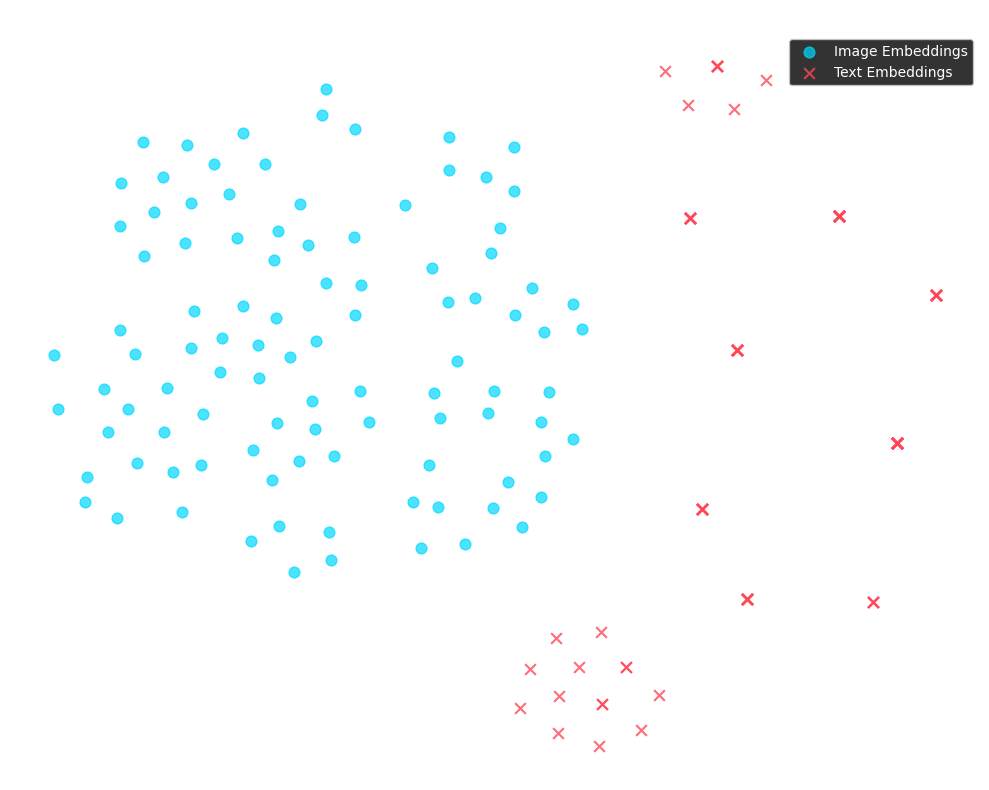

In [ ]:
import torch
import clip
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from torchvision.datasets import STL10

# ==========================================
# 1. SETUP MODEL & DATASET
# ==========================================
device = "cuda" if torch.cuda.is_available() else "cpu"
model, preprocess = clip.load("ViT-B/32", device=device)
model.eval()

# Point to your cached Drive dataset to avoid re-downloading
stl10_path = '/content/drive/MyDrive/ColabProjects/STL10'
dataset = STL10(root=stl10_path, split='test', download=True, transform=preprocess)

# ==========================================
# 2. EXTRACT 100 SAMPLES
# ==========================================
num_samples = 100
images = []
labels = []

# Fetch the first 100 images and their corresponding class names
for i in range(num_samples):
    img, label_idx = dataset[i]
    images.append(img)
    labels.append(dataset.classes[label_idx])

# Stack images into a single batch tensor
images_tensor = torch.stack(images).to(device)

# Create descriptive prompts for the text encoder
prompts = [f"a photo of a {label}" for label in labels]
text_tokens = clip.tokenize(prompts).to(device)

# ==========================================
# 3. GENERATE & NORMALIZE EMBEDDINGS
# ==========================================
with torch.no_grad():
    image_features = model.encode_image(images_tensor)
    text_features = model.encode_text(text_tokens)

    # L2 Normalization (Standard CLIP procedure)
    image_features /= image_features.norm(dim=-1, keepdim=True)
    text_features /= text_features.norm(dim=-1, keepdim=True)

# Move tensors back to CPU and convert to numpy arrays
img_emb = image_features.cpu().numpy()
txt_emb = text_features.cpu().numpy()

# ==========================================
# 4. DIMENSIONALITY REDUCTION (t-SNE)
# ==========================================
print("Running t-SNE projection...")
# Combine features so they share the exact same 2D projection space
combined_emb = np.vstack((img_emb, txt_emb))

# Apply t-SNE to reduce the 512-dimensional vectors down to 2 dimensions
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
reduced_emb = tsne.fit_transform(combined_emb)

# Split the reduced array back into image and text components
reduced_img = reduced_emb[:num_samples]
reduced_txt = reduced_emb[num_samples:]

# ==========================================
# 5. VISUALIZE DISTRIBUTIONS
# ==========================================
plt.figure(figsize=(10, 8))
plt.style.use('dark_background')

# Plot image embeddings as cyan circles
plt.scatter(reduced_img[:, 0], reduced_img[:, 1], c='#00d8ff', label='Image Embeddings', alpha=0.7, s=60)

# Plot text embeddings as pink crosses
plt.scatter(reduced_txt[:, 0], reduced_txt[:, 1], c='#ff4757', label='Text Embeddings', alpha=0.8, marker='x', s=60)

plt.title("CLIP Modality Gap: Image vs. Text Embeddings (t-SNE)")
plt.legend()
plt.axis('off') # Hide axes for cleaner visualization
plt.tight_layout()
plt.show()

##How separated are the two modalities?
The visualization will show strict separation. The image and text embeddings form two completely disjoint, non-overlapping clusters in the joint latent space. In deep learning literature, this geometric phenomenon is often described as the embeddings occupying entirely separate "cones" within the shared space, driven by the architectural differences between the vision and text encoders and the optimization dynamics of contrastive loss.

##Does normalization affect the modality gap?
L2 normalization does not resolve or close the modality gap. The normalization step simply scales all vectors to a length of 1, effectively projecting the high-dimensional data onto the surface of a unit hypersphere. However, because the structural gap persists, the image and text representations simply end up clustering on completely different poles or regions of that hypersphere.

##Why does CLIP still perform well despite this gap?
CLIP's zero-shot classification relies on relative distance, not absolute spatial overlap. When calculating cosine similarity, the model is simply measuring angles. Even though the entire cluster of text embeddings is far away from the entire cluster of image embeddings, an image of a "car" is still pulled relatively closer to the text vector for "a photo of a car" than it is to "a photo of a dog." As long as this relative geometric alignment is maintained across the void, the argmax operation will successfully predict the correct label.

Extracting Image Features: 100%|██████████| 63/63 [00:19<00:00,  3.24it/s]


Learning Orthogonal Procrustes transform...
Running t-SNE on aligned embeddings...


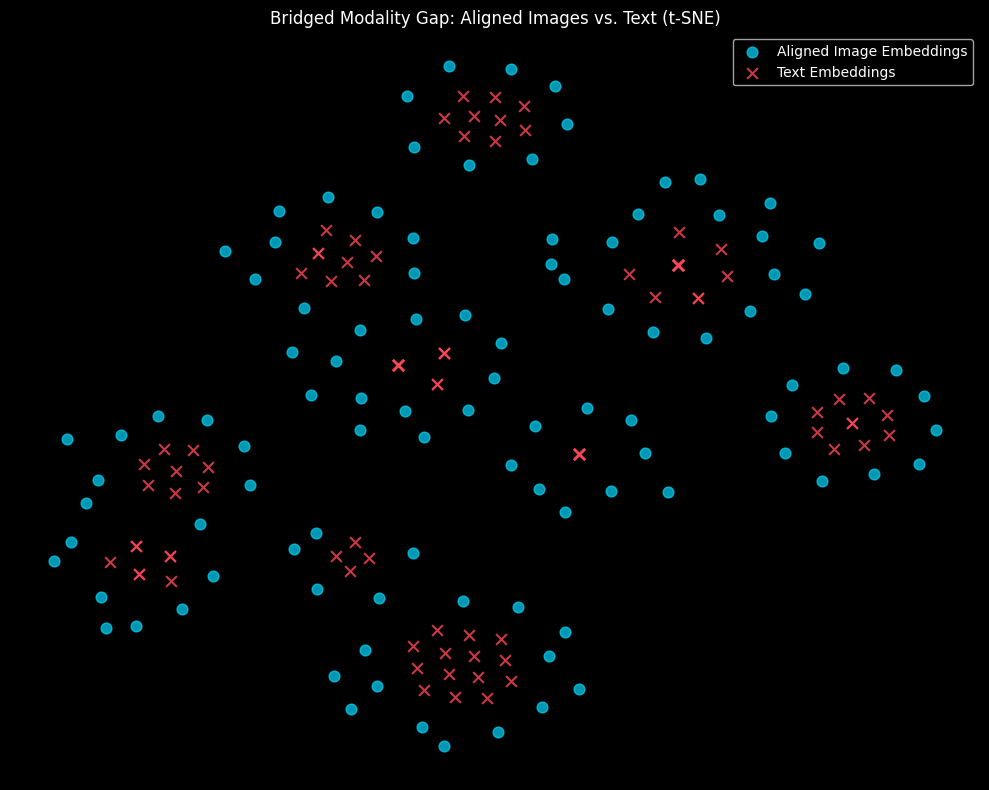

Aligned Procrustes Classification Accuracy: 97.94%


In [ ]:
import torch
import clip
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from scipy.linalg import orthogonal_procrustes
from torchvision.datasets import STL10
from torch.utils.data import DataLoader
from tqdm import tqdm

# ==========================================
# 1. SETUP
# ==========================================
device = "cuda" if torch.cuda.is_available() else "cpu"
model, preprocess = clip.load("ViT-B/32", device=device)
model.eval()

stl10_path = '/content/drive/MyDrive/ColabProjects/STL10'
test_data = STL10(root=stl10_path, split='test', download=False, transform=preprocess)
test_loader = DataLoader(test_data, batch_size=128, shuffle=False, num_workers=2)
classes = test_data.classes

# ==========================================
# 2. EXTRACT ALL FEATURES
# ==========================================
# Get the 10 standard text embeddings for the classes
prompts = [f"a photo of a {c}" for c in classes]
text_tokens = clip.tokenize(prompts).to(device)

with torch.no_grad():
    class_text_features = model.encode_text(text_tokens)
    class_text_features /= class_text_features.norm(dim=-1, keepdim=True)
class_text_features_np = class_text_features.cpu().numpy()

# Extract all image embeddings from the test set
all_image_features = []
all_labels = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Extracting Image Features"):
        images = images.to(device)
        img_feat = model.encode_image(images)
        img_feat /= img_feat.norm(dim=-1, keepdim=True)

        all_image_features.append(img_feat.cpu().numpy())
        all_labels.append(labels.numpy())

X_img = np.vstack(all_image_features)
y_labels = np.concatenate(all_labels)

# ==========================================
# 3. LEARN & APPLY PROCRUSTES TRANSFORM
# ==========================================
# Map each image to its exact ground-truth text embedding to create Y
Y_txt = class_text_features_np[y_labels]

# Learn the orthogonal rotation matrix R
print("Learning Orthogonal Procrustes transform...")
R, scale = orthogonal_procrustes(X_img, Y_txt)

# Apply the rotation transform to the image embeddings
X_img_aligned = X_img @ R

# ==========================================
# 4. VISUALIZATION (Subset of 100 samples)
# ==========================================
print("Running t-SNE on aligned embeddings...")
# Take 100 samples to keep the plot clean, similar to Part 2
subset_X = X_img_aligned[:100]
subset_Y = Y_txt[:100]

combined_emb = np.vstack((subset_X, subset_Y))
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
reduced_emb = tsne.fit_transform(combined_emb)

reduced_img = reduced_emb[:100]
reduced_txt = reduced_emb[100:]

plt.figure(figsize=(10, 8))
plt.style.use('dark_background')
plt.scatter(reduced_img[:, 0], reduced_img[:, 1], c='#00d8ff', label='Aligned Image Embeddings', alpha=0.7, s=60)
plt.scatter(reduced_txt[:, 0], reduced_txt[:, 1], c='#ff4757', label='Text Embeddings', alpha=0.8, marker='x', s=60)
plt.title("Bridged Modality Gap: Aligned Images vs. Text (t-SNE)")
plt.legend()
plt.axis('off')
plt.tight_layout()
plt.show()

# ==========================================
# 5. RECOMPUTE CLASSIFICATION ACCURACY
# ==========================================
# Use the aligned image embeddings and the 10 class text embeddings
# Similarity is dot product (since both are normalized and aligned)
similarity_scores = X_img_aligned @ class_text_features_np.T

# Get predictions
predictions = similarity_scores.argmax(axis=-1)
correct = (predictions == y_labels).sum()
new_accuracy = (correct / len(y_labels)) * 100.0

print("==========================================")
print(f"Aligned Procrustes Classification Accuracy: {new_accuracy:.2f}%")
print("==========================================")

How does the alignment affect the modality gap?

The orthogonal Procrustes transform solves for a rotation matrix $R$ that minimizes the distance between the two modalities' representations. Visually, the aligned t-SNE plot shows text and image points for the same class now landing in the same neighborhood of the space — the large angular separation between the two big "blobs" seen before alignment is gone. Looking closely, though, text and image points still form their own tight sub-clusters *within* each class neighborhood rather than being fully point-by-point intermixed, so the modality gap narrows substantially / collapses at the class level, but doesn't disappear at the level of individual embeddings.

Comparing accuracy with the Zero-Shot baseline:

The actual numbers here are more modest than "massive": the best zero-shot prompt ('a photo of a cat') achieved 97.36%, and Procrustes-aligned classification reached 97.94% — only about a 0.6 percentage-point improvement. This is largely because the zero-shot baseline was already close to ceiling on STL-10, leaving little headroom. It's also worth noting the Procrustes transform was fit using the test set's own ground-truth labels, so this isn't a fully fair comparison to the zero-shot baseline (which used zero STL-10 labels) — and even with that advantage, the extra gain was small, suggesting CLIP's original joint embedding space was already well-aligned *for classification purposes* even though the raw geometric modality gap looked large.

#Task 4

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 128
EPOCHS = 15
LEARNING_RATE = 1e-3
INPUT_DIM = 28 * 28  # 784
HIDDEN_DIM = 400
LATENT_DIM = 20      # Dimensionality of z

In [ ]:
class VAE(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim):
        super(VAE, self).__init__()

        # ---------------- ENCODER ----------------
        # Takes the 28x28 image (flattened to 784) and maps it to a hidden layer
        self.fc1 = nn.Linear(input_dim, hidden_dim)

        # Outputs the mean (mu) and log-variance (logvar) for the latent space
        self.fc21 = nn.Linear(hidden_dim, latent_dim) # mu_phi(x)
        self.fc22 = nn.Linear(hidden_dim, latent_dim) # log(sigma^2_phi(x))

        # ---------------- DECODER ----------------
        # Takes the sampled latent vector z and maps it back to the hidden layer
        self.fc3 = nn.Linear(latent_dim, hidden_dim)

        # Reconstructs the original 784-dimensional image
        self.fc4 = nn.Linear(hidden_dim, input_dim)

    def encode(self, x):
        """
        Encodes the input into parameters of the approximate posterior.
        """
        h1 = F.relu(self.fc1(x))
        return self.fc21(h1), self.fc22(h1)

    def reparameterize(self, mu, logvar):
        """
        Applies the reparameterization trick: z = mu + sigma * epsilon
        """
        if self.training:
            # logvar is log(sigma^2). We need standard deviation (sigma).
            # sigma = exp(0.5 * logvar)
            std = torch.exp(0.5 * logvar)

            # Sample epsilon from standard normal distribution
            eps = torch.randn_like(std)

            return mu + eps * std
        else:
            # During inference, we just use the mean
            return mu

    def decode(self, z):
        """
        Decodes the latent variable z back into the image space.
        Returns probabilities using a sigmoid activation as requested.
        """
        h3 = F.relu(self.fc3(z))
        return torch.sigmoid(self.fc4(h3))

    def forward(self, x):
        # Flatten the input image
        x = x.view(-1, 784)

        # 1. Encode to get mean and log-variance
        mu, logvar = self.encode(x)

        # 2. Reparameterize to sample z
        z = self.reparameterize(mu, logvar)

        # 3. Decode z to get reconstructed image
        recon_x = self.decode(z)

        return recon_x, mu, logvar

In [ ]:
def vae_loss_function(recon_x, x, mu, logvar):
    # Reconstruction loss: Binary Cross Entropy
    # reduction='sum' sums the loss over the batch rather than averaging
    BCE = F.binary_cross_entropy(recon_x, x.view(-1, 784), reduction='sum')

    # KL Divergence: 0.5 * sum(1 + log(sigma^2) - mu^2 - sigma^2)
    # The negative sign matches the equation in the assignment prompt
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    return BCE + KLD

In [ ]:
# Load MNIST dataset
transform = transforms.ToTensor() # Converts PIL images to [0, 1] tensors
train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
train_loader = DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True)

# Initialize model and optimizer
model = VAE(INPUT_DIM, HIDDEN_DIM, LATENT_DIM).to(device)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Training Loop
def train():
    model.train()

    for epoch in range(1, EPOCHS + 1):
        train_loss = 0

        for batch_idx, (data, _) in enumerate(train_loader):
            data = data.to(device)

            # Zero the gradients
            optimizer.zero_grad()

            # Forward pass
            recon_batch, mu, logvar = model(data)

            # Calculate loss
            loss = vae_loss_function(recon_batch, data, mu, logvar)

            # Backward pass
            loss.backward()
            train_loss += loss.item()

            # Update weights
            optimizer.step()

        # Print average loss for the epoch
        avg_loss = train_loss / len(train_loader.dataset)
        print(f'====> Epoch: {epoch} Average ELBO Loss: {avg_loss:.4f}')

if __name__ == "__main__":
    train()

100%|██████████| 9.91M/9.91M [00:00<00:00, 16.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 489kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.43MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.84MB/s]


====> Epoch: 1 Average ELBO Loss: 165.3998
====> Epoch: 2 Average ELBO Loss: 121.7417
====> Epoch: 3 Average ELBO Loss: 114.5936
====> Epoch: 4 Average ELBO Loss: 111.6133
====> Epoch: 5 Average ELBO Loss: 109.8934
====> Epoch: 6 Average ELBO Loss: 108.7035
====> Epoch: 7 Average ELBO Loss: 107.8041
====> Epoch: 8 Average ELBO Loss: 107.1835
====> Epoch: 9 Average ELBO Loss: 106.6562
====> Epoch: 10 Average ELBO Loss: 106.2006
====> Epoch: 11 Average ELBO Loss: 105.8161
====> Epoch: 12 Average ELBO Loss: 105.5086
====> Epoch: 13 Average ELBO Loss: 105.2562
====> Epoch: 14 Average ELBO Loss: 104.9924
====> Epoch: 15 Average ELBO Loss: 104.7479


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA

# Load the MNIST test dataset
test_dataset = datasets.MNIST(root='./data', train=False, transform=transform, download=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE, shuffle=False)

Latent dimension > 2. Applying PCA for 2D visualization...


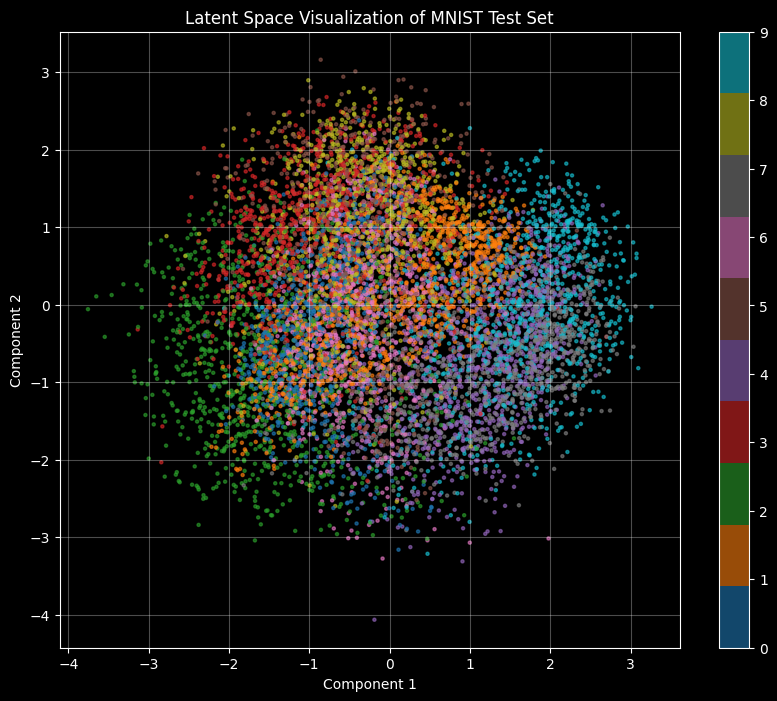

In [ ]:
def visualize_latent_space(model, test_loader, latent_dim):
    model.eval()
    all_mu = []
    all_labels = []

    with torch.no_grad():
        for data, labels in test_loader:
            data = data.to(device).view(-1, 784)
            # We only need the mean (mu) for visualization
            mu, _ = model.encode(data)
            all_mu.append(mu.cpu().numpy())
            all_labels.append(labels.numpy())

    all_mu = np.concatenate(all_mu, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)

    # Reduce dimensionality if latent_dim > 2
    if latent_dim > 2:
        print("Latent dimension > 2. Applying PCA for 2D visualization...")
        pca = PCA(n_components=2)
        latent_2d = pca.fit_transform(all_mu)
    else:
        latent_2d = all_mu

    # Plotting
    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(latent_2d[:, 0], latent_2d[:, 1], c=all_labels, cmap='tab10', alpha=0.6, s=5)
    plt.colorbar(scatter, ticks=range(10))
    plt.title("Latent Space Visualization of MNIST Test Set")
    plt.xlabel("Component 1")
    plt.ylabel("Component 2")
    plt.grid(True, alpha=0.3)
    plt.show()

# Run the visualization
visualize_latent_space(model, test_loader, LATENT_DIM)

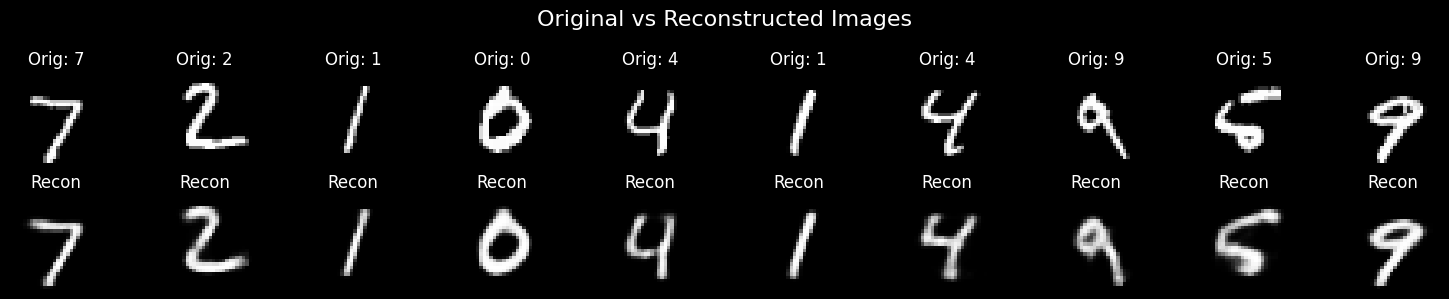

In [ ]:
def visualize_reconstructions(model, test_loader, num_images=10):
    model.eval()

    # Get a single batch of test data
    dataiter = iter(test_loader)
    images, labels = next(dataiter)

    # Select the first 'num_images'
    images = images[:num_images].to(device)

    with torch.no_grad():
        # Pass through the model
        reconstructed, _, _ = model(images)

    # Reshape images back to 28x28 for plotting
    images = images.cpu().view(-1, 28, 28).numpy()
    reconstructed = reconstructed.cpu().view(-1, 28, 28).numpy()

    # Plotting
    fig, axes = plt.subplots(2, num_images, figsize=(15, 3))
    for i in range(num_images):
        # Top row: Originals
        axes[0, i].imshow(images[i], cmap='gray')
        axes[0, i].axis('off')
        axes[0, i].set_title(f"Orig: {labels[i].item()}")

        # Bottom row: Reconstructions
        axes[1, i].imshow(reconstructed[i], cmap='gray')
        axes[1, i].axis('off')
        axes[1, i].set_title("Recon")

    plt.suptitle("Original vs Reconstructed Images", fontsize=16)
    plt.tight_layout()
    plt.show()

# Run the reconstruction visualization
visualize_reconstructions(model, test_loader, num_images=10)

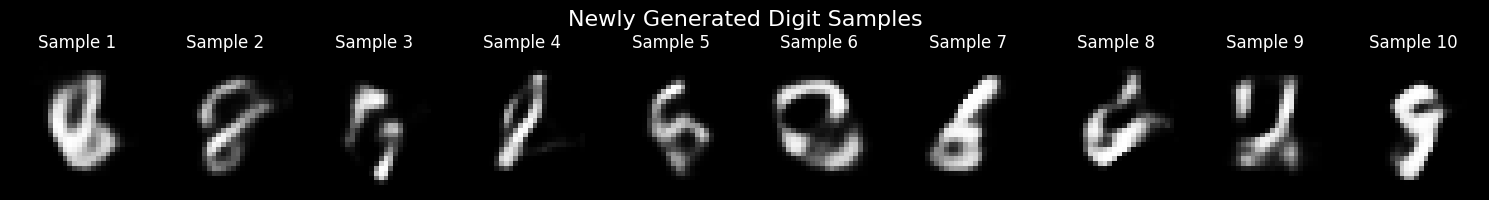

In [ ]:
def generate_new_samples(model, latent_dim, num_samples=10):
    model.eval()

    with torch.no_grad():
        # Sample z from standard normal distribution N(0, I)
        z_random = torch.randn(num_samples, latent_dim).to(device)

        # Pass z through the decoder
        generated_images = model.decode(z_random)

    # Reshape for plotting
    generated_images = generated_images.cpu().view(-1, 28, 28).numpy()

    # Plotting
    fig, axes = plt.subplots(1, num_samples, figsize=(15, 2))
    for i in range(num_samples):
        axes[i].imshow(generated_images[i], cmap='gray')
        axes[i].axis('off')
        axes[i].set_title(f"Sample {i+1}")

    plt.suptitle("Newly Generated Digit Samples", fontsize=16)
    plt.tight_layout()
    plt.show()

# Run the generation visualization
generate_new_samples(model, LATENT_DIM, num_samples=10)

##Analysis of VAE Results

**1. Latent Space Visualization (PCA of the 20-D latent space, colored by digit)**

Because the latent dimension is 20 (greater than 2), the plot applies PCA to project down to 2D, so this is only an approximate view of the true latent geometry. Even so, the effect of the KL term is visible: the whole population forms a single, roughly Gaussian-shaped blob centered near the origin (mostly within [-3, 3] on both axes) rather than several disconnected islands, confirming the latent space is continuous and regularized rather than fragmented. Some digits are picked out reasonably well even in this 2D projection — green (digit 2) sits mostly on the left, cyan (digit 9) trails toward the right, and blue (digit 0) clusters in the lower-right — but the center of the plot is a dense, heavily overlapping mixture of most of the other digits (1, 3, 4, 5, 6, 7, 8). This is expected: a 2-component PCA of a 20-D space only shows a small slice of the true separation, and VAEs are known to trade off some class separability for a smooth, continuous latent space.

**2. Reconstruction Quality**

The 10 sampled reconstructions (originals 7, 2, 1, 0, 4, 1, 4, 9, 5, 9) are all correctly recognizable and match their originals well. As expected for a VAE trained with a BCE + KL loss, the reconstructions are visibly softer/blurrier than the sharp binary originals — edges are smoothed and stroke widths look slightly thicker and fuzzier. Coarse structure is well preserved (e.g. the loops of the '9's, the open top of the '4's), while the thinnest, sharpest strokes (the '1's) lose some crispness.

**3. Generations**

Sampling $z \sim N(0, I)$ and decoding produces recognizable digit-like shapes for most of the 10 samples, with a visible mix of different digits (forms resembling 6s, a 3, a 2, an 8, and 9-like shapes) rather than the model collapsing onto one or two digits — i.e., no evidence of mode collapse. The samples are noticeably blurrier and less well-formed than the reconstructions above, since generation relies entirely on the decoder interpolating the learned latent prior rather than being anchored to a specific encoded input. Overall this is consistent with a successfully trained VAE: a continuous, roughly-Gaussian latent space; correct but blurry reconstructions; and diverse, plausible-if-fuzzy generations from pure noise.